# HFT Pipeline Demo: end-to-end walkthrough

This notebook drives the pipeline in `hft/` end to end: market data ingestion,
the ring buffer, the strategy engine, the paper execution venue, and the
latency instrumentation.

**Caveat, restated from the README:** `yfinance` is an unofficial Yahoo
Finance scraper with no SLA and multi-second delay on "real-time" fields.
Section 1 pulls a few *real* live ticks to prove the ingestion path works
end to end. Section 2 switches to a small deterministic synthetic price
series so the moving-average crossover strategy has something to actually
cross within a few cells, instead of hoping live prices move enough in the
time it takes to run this notebook.

In [1]:
import asyncio
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt

from hft.core.engine import StrategyEngine
from hft.core.ringbuffer import RingBuffer
from hft.core.strategy import MovingAverageCrossoverStrategy
from hft.data.base import Tick
from hft.data.yfinance_source import YFinanceSource
from hft.execution.paper import PaperExecutionVenue
from hft.metrics.timing import LatencyRecorder

print("imports ok")

imports ok


## 1. Live tick ingestion via `YFinanceSource`

Pulls a handful of real ticks for two symbols to prove `MarketDataSource ->
Tick` works against the live yfinance endpoint, and shows the per-tick
`source_ts_ns` / `ingest_ts_ns` timestamps that latency measurement is
built on.

In [2]:
async def collect_live_ticks(symbols, n_per_symbol=2):
    source = YFinanceSource(poll_interval_s=1.5)
    collected = []
    seen = {s: 0 for s in symbols}
    async for tick in source.stream(symbols):
        collected.append(tick)
        seen[tick.symbol] += 1
        if all(count >= n_per_symbol for count in seen.values()):
            break
    return collected


live_ticks = await collect_live_ticks(["AAPL", "MSFT"])
for t in live_ticks:
    print(f"{t.symbol:5s} price={t.price:>10.2f} volume={t.volume} ingest_ts_ns={t.ingest_ts_ns}")

AAPL  price=    314.86 volume=36328962 ingest_ts_ns=1784074599634974500
MSFT  price=    384.93 volume=27858198 ingest_ts_ns=1784074599959008700
AAPL  price=    314.86 volume=36328962 ingest_ts_ns=1784074600489965300
MSFT  price=    384.93 volume=27858198 ingest_ts_ns=1784074600490922700


## 2. Ring buffer -> strategy engine -> paper execution venue

A deterministic synthetic price series (dip then rally) that reliably
triggers a bullish moving-average crossover, so the demo output is
reproducible regardless of live market conditions. Ticks are pushed onto
the `RingBuffer`, then `StrategyEngine.run_forever()` drains it: each tick
runs through `MovingAverageCrossoverStrategy`, and any signal is submitted
to `PaperExecutionVenue`.

In [3]:
def make_tick(symbol: str, price: float) -> Tick:
    return Tick(symbol=symbol, price=price, volume=1_000, source_ts_ns=time.time_ns())


synthetic_prices = [100, 99, 98, 97, 96, 95, 103, 108, 112, 115, 118, 120]

buffer: RingBuffer[Tick] = RingBuffer(capacity=32)
strategy = MovingAverageCrossoverStrategy(fast_window=3, slow_window=6)
venue = PaperExecutionVenue(slippage_bps=1.0, fee_bps=0.5)
recorder = LatencyRecorder()
engine = StrategyEngine(buffer, strategy, venue, recorder, order_quantity=10)

for p in synthetic_prices:
    buffer.push(make_tick("AAPL", p))


async def drain_engine():
    task = asyncio.create_task(engine.run_forever())
    for _ in range(200):
        if len(buffer) == 0:
            break
        await asyncio.sleep(0.005)
    engine.stop()
    buffer.push(make_tick("AAPL", synthetic_prices[-1]))  # unblock the final pop()
    await asyncio.wait_for(task, timeout=2)


await drain_engine()

print("positions:   ", venue.positions)
print("realized_pnl:", round(venue.realized_pnl, 4))
print("dropped ticks:", buffer.dropped)

positions:    {'AAPL': 10}
realized_pnl: -0.054
dropped ticks: 0


## 3. Latency instrumentation

Stage-boundary nanosecond timings recorded by `LatencyRecorder` for every tick processed above.

In [4]:
summary = recorder.summary()
for k, v in summary.items():
    print(f"{k}: {v}")

count: 13
ingest_to_signal_ns_p50: 923700.0
ingest_to_signal_ns_p99: 1047324.0
order_round_trip_ns_p50: 26600.0
order_round_trip_ns_p99: 26600.0


## 4. Visualize price, moving averages, and signals

Fast/slow moving averages computed the same way the strategy computes them
internally, with markers at the crossover points that produced BUY/SELL
signals.

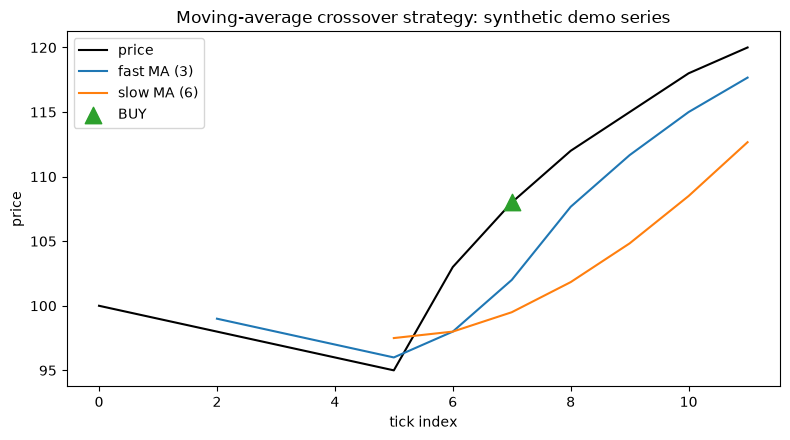

In [5]:
fast_w, slow_w = strategy.fast_window, strategy.slow_window

def rolling_avg(values, window):
    out = []
    for i in range(len(values)):
        if i + 1 < window:
            out.append(None)
        else:
            out.append(sum(values[i + 1 - window : i + 1]) / window)
    return out

fast_avgs = rolling_avg(synthetic_prices, fast_w)
slow_avgs = rolling_avg(synthetic_prices, slow_w)

replay_strategy = MovingAverageCrossoverStrategy(fast_window=fast_w, slow_window=slow_w)
signal_points = []
for i, p in enumerate(synthetic_prices):
    sig = replay_strategy.on_tick(make_tick("AAPL", p))
    if sig is not None:
        signal_points.append((i, p, sig.side))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(synthetic_prices, label="price", color="black", linewidth=1.5)
ax.plot(fast_avgs, label=f"fast MA ({fast_w})", color="tab:blue")
ax.plot(slow_avgs, label=f"slow MA ({slow_w})", color="tab:orange")

for i, p, side in signal_points:
    color = "tab:green" if side == "BUY" else "tab:red"
    marker = "^" if side == "BUY" else "v"
    ax.scatter([i], [p], color=color, marker=marker, s=140, zorder=5, label=side)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_xlabel("tick index")
ax.set_ylabel("price")
ax.set_title("Moving-average crossover strategy: synthetic demo series")
plt.tight_layout()
plt.show()

## Summary

- `YFinanceSource` pulled real ticks end to end in section 1.
- The `RingBuffer -> StrategyEngine -> PaperExecutionVenue` pipeline
  correctly detected a crossover in section 2 and produced a fill with
  slippage/fees applied.
- `LatencyRecorder` captured nanosecond-resolution stage timings for every
  tick processed.

See `README.md` for the honest limitations of using yfinance for real HFT,
and the concrete path to swap in a real feed/broker behind the same
`MarketDataSource` / `ExecutionVenue` interfaces.